# ML Zoomcamp 2026 — Homework 2

## Module 2: Machine Learning for Regression

This notebook solves Homework 2 using the pinned 2026 Car Fuel Efficiency dataset.

### Canidate Name / Student Name:
Rishi P Kulkarni

### Objective

Build and evaluate linear regression models for predicting:

`fuel_efficiency_mpg`

### Features

- `engine_displacement`
- `horsepower`
- `vehicle_weight`
- `model_year`

Cell 2 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 2.2.3
NumPy: 2.1.3


Cell 3 — Load dataset

In [2]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10000, 11)


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


Cell 4 — Select required columns

In [3]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]

target = "fuel_efficiency_mpg"

df = df[features + [target]]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


Cell 5 — EDA: target distribution

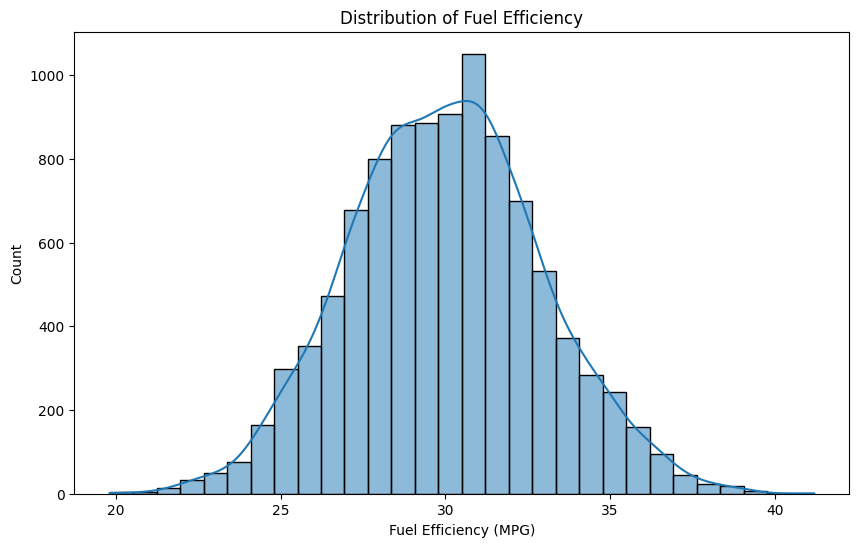

Target skewness: 0.08080419601878173


In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(df[target], bins=30, kde=True)

plt.title("Distribution of Fuel Efficiency")
plt.xlabel("Fuel Efficiency (MPG)")
plt.ylabel("Count")

plt.show()

print("Target skewness:", df[target].skew())

Cell 6 — Missing values

In [5]:
missing = df.isnull().sum()

print("Missing values by column:")
print(missing)

print("\nColumn with missing values:")

for column in df.columns:
    if missing[column] > 0:
        print(column, "→", missing[column])

Missing values by column:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Column with missing values:
horsepower → 877


Cell 7 — Median horsepower

In [6]:
median_horsepower = df["horsepower"].median()

print("Median horsepower:", median_horsepower)

Median horsepower: 254.0


Cell 8 — Train/validation/test split function

In [7]:
def split_data(df, seed=42):
    n = len(df)

    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test

Cell 9 — Split with seed 42

In [8]:
df_train, df_val, df_test = split_data(df, seed=42)

print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

Train: (6000, 5)
Validation: (2000, 5)
Test: (2000, 5)


Cell 10 — Linear regression

In [9]:
def train_linear_regression(X, y):
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)

    w = XTX_inv @ X.T @ y

    return w


def train_linear_regression_reg(X, y, r=0.0):
    XTX = X.T @ X

    reg = r * np.eye(XTX.shape[0])

    XTX_reg = XTX + reg

    XTX_inv = np.linalg.inv(XTX_reg)

    w = XTX_inv @ X.T @ y

    return w


def predict(X, w):
    return X @ w


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

Cell 11 — Helper for preparing X

In [10]:
def prepare_X(df):
    X = df[features].copy()

    return X.values

Cell 12 — Q3: Fill with zero

In [11]:
train_zero = df_train.copy()
val_zero = df_val.copy()

train_zero["horsepower"] = train_zero["horsepower"].fillna(0)
val_zero["horsepower"] = val_zero["horsepower"].fillna(0)

X_train = prepare_X(train_zero)
X_val = prepare_X(val_zero)

y_train = train_zero[target].values
y_val = val_zero[target].values

# Add intercept
X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_val = np.column_stack([np.ones(X_val.shape[0]), X_val])

w_zero = train_linear_regression(X_train, y_train)

y_pred_zero = predict(X_val, w_zero)

rmse_zero = rmse(y_val, y_pred_zero)

print("RMSE with zero:", round(rmse_zero, 3))

RMSE with zero: 2.205


Cell 13 — Q3: Fill with training mean

In [12]:
train_mean = df_train.copy()
val_mean = df_val.copy()

horsepower_mean = train_mean["horsepower"].mean()

train_mean["horsepower"] = train_mean["horsepower"].fillna(horsepower_mean)
val_mean["horsepower"] = val_mean["horsepower"].fillna(horsepower_mean)

X_train = prepare_X(train_mean)
X_val = prepare_X(val_mean)

y_train = train_mean[target].values
y_val = val_mean[target].values

X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_val = np.column_stack([np.ones(X_val.shape[0]), X_val])

w_mean = train_linear_regression(X_train, y_train)

y_pred_mean = predict(X_val, w_mean)

rmse_mean = rmse(y_val, y_pred_mean)

print("Training horsepower mean:", horsepower_mean)
print("RMSE with mean:", round(rmse_mean, 3))

Training horsepower mean: 254.46338337605272
RMSE with mean: 2.202


Cell 14 — Compare Q3

In [13]:
print("Q3 Results")
print("-" * 30)

print("RMSE with 0:   ", round(rmse_zero, 3))
print("RMSE with mean:", round(rmse_mean, 3))

if rmse_zero < rmse_mean:
    print("\nBetter option: With 0")
elif rmse_mean < rmse_zero:
    print("\nBetter option: With mean")
else:
    print("\nBoth are equally good")

Q3 Results
------------------------------
RMSE with 0:    2.205
RMSE with mean: 2.202

Better option: With mean


Cell 15 — Q4

In [14]:
train_reg = df_train.copy()
val_reg = df_val.copy()

train_reg["horsepower"] = train_reg["horsepower"].fillna(0)
val_reg["horsepower"] = val_reg["horsepower"].fillna(0)

X_train = prepare_X(train_reg)
X_val = prepare_X(val_reg)

y_train = train_reg[target].values
y_val = val_reg[target].values

X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_val = np.column_stack([np.ones(X_val.shape[0]), X_val])

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

results_q4 = []

for r in r_values:
    w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = predict(X_val, w)

    score = rmse(y_val, y_pred)

    results_q4.append((r, score))

print("Q4 — Regularization results")
print("-" * 40)

for r, score in results_q4:
    print(f"r = {r:<6} RMSE = {score:.4f}")

best_r, best_score = min(results_q4, key=lambda x: (round(x[1], 4), x[0]))

print("\nBest r:", best_r)
print("Best RMSE:", round(best_score, 4))

Q4 — Regularization results
----------------------------------------
r = 0      RMSE = 2.2053
r = 0.01   RMSE = 2.2058
r = 0.1    RMSE = 2.2241
r = 1      RMSE = 2.3492
r = 5      RMSE = 2.4094
r = 10     RMSE = 2.4195
r = 100    RMSE = 2.4292

Best r: 0
Best RMSE: 2.2053


Cell 16 — Q5

In [15]:
seeds = list(range(10))

scores_q5 = []

for seed in seeds:

    # Split
    df_train_seed, df_val_seed, df_test_seed = split_data(df, seed=seed)

    # Fill missing values with 0
    df_train_seed = df_train_seed.copy()
    df_val_seed = df_val_seed.copy()

    df_train_seed["horsepower"] = df_train_seed["horsepower"].fillna(0)
    df_val_seed["horsepower"] = df_val_seed["horsepower"].fillna(0)

    # Prepare X and y
    X_train = prepare_X(df_train_seed)
    X_val = prepare_X(df_val_seed)

    y_train = df_train_seed[target].values
    y_val = df_val_seed[target].values

    # Add intercept
    X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])
    X_val = np.column_stack([np.ones(X_val.shape[0]), X_val])

    # Train
    w = train_linear_regression(X_train, y_train)

    # Predict
    y_pred = predict(X_val, w)

    # RMSE
    score = rmse(y_val, y_pred)

    scores_q5.append(score)

print("Q5 — RMSE for each seed")
print("-" * 35)

for seed, score in zip(seeds, scores_q5):
    print(f"Seed {seed}: RMSE = {score:.6f}")

std_q5 = np.std(scores_q5)

print("\nStandard deviation:", std_q5)
print("Rounded:", round(std_q5, 3))

Q5 — RMSE for each seed
-----------------------------------
Seed 0: RMSE = 2.239204
Seed 1: RMSE = 2.202113
Seed 2: RMSE = 2.163420
Seed 3: RMSE = 2.204359
Seed 4: RMSE = 2.201880
Seed 5: RMSE = 2.245785
Seed 6: RMSE = 2.269721
Seed 7: RMSE = 2.190795
Seed 8: RMSE = 2.216611
Seed 9: RMSE = 2.207037

Standard deviation: 0.028781274078187463
Rounded: 0.029


Cell 17 — Q6

In [16]:
# Split with seed 9
df_train, df_val, df_test = split_data(df, seed=9)

# Combine train and validation
df_train_full = pd.concat([df_train, df_val])

# Fill missing horsepower with 0
df_train_full = df_train_full.copy()
df_test = df_test.copy()

df_train_full["horsepower"] = df_train_full["horsepower"].fillna(0)
df_test["horsepower"] = df_test["horsepower"].fillna(0)

# Prepare training data
X_train_full = prepare_X(df_train_full)
y_train_full = df_train_full[target].values

# Prepare test data
X_test = prepare_X(df_test)
y_test = df_test[target].values

# Add intercept
X_train_full = np.column_stack([
    np.ones(X_train_full.shape[0]),
    X_train_full
])

X_test = np.column_stack([
    np.ones(X_test.shape[0]),
    X_test
])

# Train regularized model
w_final = train_linear_regression_reg(
    X_train_full,
    y_train_full,
    r=0.001
)

# Predict
y_pred_test = predict(X_test, w_final)

# RMSE
rmse_test = rmse(y_test, y_pred_test)

print("Q6 — Final test RMSE:", rmse_test)
print("Rounded:", round(rmse_test, 3))

Q6 — Final test RMSE: 2.235827747191763
Rounded: 2.236


Cell 18 — Final answers

In [17]:
print("=" * 55)
print("ML ZOOMCAMP 2026 — HOMEWORK 2")
print("FINAL ANSWERS")
print("=" * 55)

print(f"Q1 — Missing column: horsepower")
print(f"Q2 — Median horsepower: {median_horsepower}")
print(f"Q3 — Better imputation: ", end="")

if rmse_zero < rmse_mean:
    print("With 0")
elif rmse_mean < rmse_zero:
    print("With mean")
else:
    print("Both are equally good")

print(f"Q4 — Best r: {best_r}")
print(f"Q5 — Standard deviation: {round(std_q5, 3)}")
print(f"Q6 — Test RMSE: {rmse_test:.3f}")

print("=" * 55)

ML ZOOMCAMP 2026 — HOMEWORK 2
FINAL ANSWERS
Q1 — Missing column: horsepower
Q2 — Median horsepower: 254.0
Q3 — Better imputation: With mean
Q4 — Best r: 0
Q5 — Standard deviation: 0.029
Q6 — Test RMSE: 2.236
